Pradeep Manikandan D 
24BAD088

# PART A: DATASET PREPARATION AND IMAGE PREPROCESSING

In this section, the MNIST dataset is loaded, explored, visualized, normalized to the range **[-1, 1]**, reshaped, and prepared as a TensorFlow data pipeline for batch-wise training.


In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
print("TensorFlow version:", tf.__version__)
print("Num GPUs Available:", len(tf.config.list_physical_devices('GPU')))


TensorFlow version: 2.21.0
Num GPUs Available: 0


In [2]:
# Load the MNIST dataset
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

print("Training images shape:", x_train.shape)
print("Training labels shape:", y_train.shape)
print("Testing images shape:", x_test.shape)
print("Testing labels shape:", y_test.shape)
print("Image dimensions:", x_train.shape[1:])
print("Number of training images:", len(x_train))
print("Number of testing images:", len(x_test))


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 20s 2us/step
Training images shape: (60000, 28, 28)
Training labels shape: (60000,)
Testing images shape: (10000, 28, 28)
Testing labels shape: (10000,)
Image dimensions: (28, 28)
Number of training images: 60000
Number of testing images: 10000


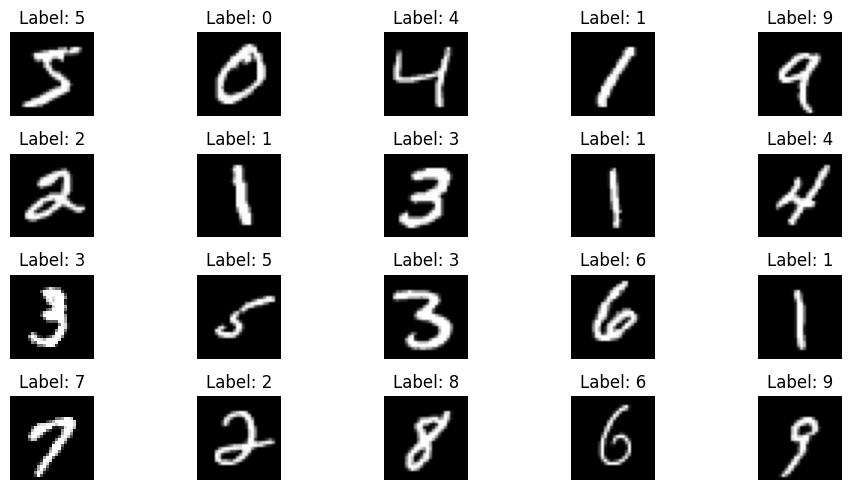

In [3]:
# Display sample images
plt.figure(figsize=(10, 5))

for i in range(20):
    plt.subplot(4, 5, i + 1)
    plt.imshow(x_train[i], cmap="gray")
    plt.title(f"Label: {y_train[i]}")
    plt.axis("off")

plt.tight_layout()
plt.show()


In [4]:
# Check pixel-value range before preprocessing
print("Minimum pixel value:", x_train.min())
print("Maximum pixel value:", x_train.max())

# Normalize pixel values from [0, 255] to [-1, 1]
x_train = x_train.astype("float32")
x_train = (x_train - 127.5) / 127.5

# Add channel dimension: (N, 28, 28) -> (N, 28, 28, 1)
x_train = np.expand_dims(x_train, axis=-1)

print("After preprocessing:")
print("Shape:", x_train.shape)
print("Minimum pixel value:", x_train.min())
print("Maximum pixel value:", x_train.max())


Minimum pixel value: 0
Maximum pixel value: 255
After preprocessing:
Shape: (60000, 28, 28, 1)
Minimum pixel value: -1.0
Maximum pixel value: 1.0


In [5]:
# Create TensorFlow data pipeline
BATCH_SIZE = 128
BUFFER_SIZE = 60000

train_dataset = (
    tf.data.Dataset.from_tensor_slices(x_train)
    .shuffle(BUFFER_SIZE)
    .batch(BATCH_SIZE, drop_remainder=True)
    .prefetch(tf.data.AUTOTUNE)
)

print("Batch size:", BATCH_SIZE)

for batch in train_dataset.take(1):
    print("One batch shape:", batch.shape)


Batch size: 128
One batch shape: (128, 28, 28, 1)


# PART B: IMPLEMENTING THE GENERATOR

The Generator receives a random noise vector and transforms it into a 28×28×1 image. Dense and transposed-convolution layers are used to progressively transform the latent vector into an image.


In [6]:
# Define Generator parameters
LATENT_DIM = 100

def build_generator():
    model = keras.Sequential(name="Generator")

    model.add(layers.Input(shape=(LATENT_DIM,)))

    # Convert noise vector into a small feature map
    model.add(layers.Dense(7 * 7 * 128, use_bias=False))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())

    model.add(layers.Reshape((7, 7, 128)))

    # Upsample: 7x7 -> 14x14
    model.add(layers.Conv2DTranspose(
        64, kernel_size=5, strides=2, padding="same", use_bias=False
    ))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())

    # Upsample: 14x14 -> 28x28
    model.add(layers.Conv2DTranspose(
        1, kernel_size=5, strides=2, padding="same",
        use_bias=False, activation="tanh"
    ))

    return model

generator = build_generator()
generator.summary()


Model: "Generator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 6272)           │       627,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 6272)           │        25,088 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 14, 14, 64)     │       204,800 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 28, 28, 1)      │         1,600 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 858,944 (3.28 MB)

 Trainable params: 846,272 (3.23 MB)

 Non-trainable params: 12,672 (49.50 KB)

In [7]:
# Generate an image before GAN training
random_noise = tf.random.normal([1, LATENT_DIM])
generated_image = generator(random_noise, training=False)

print("Generated image shape:", generated_image.shape)


Generated image shape: (1, 28, 28, 1)


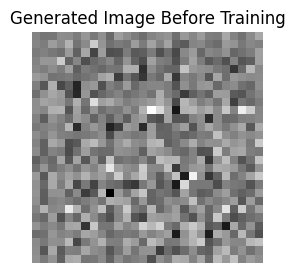

In [8]:
# Display generated image before training
plt.figure(figsize=(3, 3))
plt.imshow(generated_image[0, :, :, 0], cmap="gray")
plt.title("Generated Image Before Training")
plt.axis("off")
plt.show()


# PART C: IMPLEMENTING THE DISCRIMINATOR AND GAN MODEL

The Discriminator classifies an image as either **real (1)** or **synthetic/fake (0)**. It uses convolutional layers to extract image features and a final sigmoid output for binary classification.


In [9]:
def build_discriminator():
    model = keras.Sequential(name="Discriminator")

    model.add(layers.Input(shape=(28, 28, 1)))

    model.add(layers.Conv2D(
        64, kernel_size=5, strides=2, padding="same"
    ))
    model.add(layers.LeakyReLU())
    model.add(layers.Dropout(0.3))

    model.add(layers.Conv2D(
        128, kernel_size=5, strides=2, padding="same"
    ))
    model.add(layers.LeakyReLU())
    model.add(layers.Dropout(0.3))

    model.add(layers.Flatten())
    model.add(layers.Dense(1, activation="sigmoid"))

    return model

discriminator = build_discriminator()
discriminator.summary()


Model: "Discriminator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 14, 14, 64)     │         1,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 7, 7, 128)      │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │         6,273 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 212,865 (831.50 KB)

 Trainable params: 212,865 (831.50 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Define loss function and optimizer
cross_entropy = keras.losses.BinaryCrossentropy(from_logits=False)
generator_optimizer = keras.optimizers.Adam(
    learning_rate=0.0002, beta_1=0.5
)
discriminator_optimizer = keras.optimizers.Adam(
    learning_rate=0.0002, beta_1=0.5
)
print("Loss function: Binary Cross-Entropy")
print("Optimizer: Adam")


Loss function: Binary Cross-Entropy
Optimizer: Adam


In [11]:
# Test the Discriminator with real and generated images
real_batch = next(iter(train_dataset))
fake_batch = generator(
    tf.random.normal([BATCH_SIZE, LATENT_DIM]),
    training=False
)

real_predictions = discriminator(real_batch, training=False)
fake_predictions = discriminator(fake_batch, training=False)

print("Real prediction shape:", real_predictions.shape)
print("Fake prediction shape:", fake_predictions.shape)
print("Example real prediction:", float(real_predictions[0][0]))
print("Example fake prediction:", float(fake_predictions[0][0]))


Real prediction shape: (128, 1)
Fake prediction shape: (128, 1)
Example real prediction: 0.5238209366798401
Example fake prediction: 0.5008296966552734


## GAN Architecture

The complete GAN consists of:

**Random Noise → Generator → Synthetic Image → Discriminator → Real/Fake Prediction**

During training, the Generator attempts to fool the Discriminator, while the Discriminator learns to distinguish real images from generated images.


# PART D: GAN TRAINING AND SYNTHETIC IMAGE GENERATION

The custom training loop below alternates between:
1. Training the Discriminator using real and generated images.
2. Training the Generator so that generated images are classified as real.
3. Recording Generator and Discriminator losses.
4. Generating sample images at regular intervals.


In [ ]:
# Training configuration
EPOCHS = 30
NUM_EXAMPLES_TO_GENERATE = 16
# Fixed seed allows comparison of image quality during training
seed = tf.random.normal([NUM_EXAMPLES_TO_GENERATE, LATENT_DIM])
generator_losses = []
discriminator_losses = []
generated_snapshots = []
print("Epochs:", EPOCHS)
print("Batch size:", BATCH_SIZE)
print("Latent dimension:", LATENT_DIM)


Epochs: 30
Batch size: 128
Latent dimension: 100


In [13]:
@tf.function
def train_step(images):
    # Generate random noise
    noise = tf.random.normal([BATCH_SIZE, LATENT_DIM])

    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
        # Generate synthetic images
        generated_images = generator(noise, training=True)

        # Discriminator predictions
        real_output = discriminator(images, training=True)
        fake_output = discriminator(generated_images, training=True)

        # Calculate Generator loss
        gen_loss = cross_entropy(
            tf.ones_like(fake_output), fake_output
        )

        # Calculate Discriminator loss
        real_loss = cross_entropy(
            tf.ones_like(real_output), real_output
        )
        fake_loss = cross_entropy(
            tf.zeros_like(fake_output), fake_output
        )

        disc_loss = real_loss + fake_loss

    # Calculate gradients
    gradients_of_generator = gen_tape.gradient(
        gen_loss, generator.trainable_variables
    )

    gradients_of_discriminator = disc_tape.gradient(
        disc_loss, discriminator.trainable_variables
    )

    # Update model weights
    generator_optimizer.apply_gradients(
        zip(gradients_of_generator, generator.trainable_variables)
    )

    discriminator_optimizer.apply_gradients(
        zip(gradients_of_discriminator, discriminator.trainable_variables)
    )

    return gen_loss, disc_loss


In [ ]:
for epoch in range(1, EPOCHS + 1):
    epoch_gen_losses = []
    epoch_disc_losses = []
    for image_batch in train_dataset:
        gen_loss, disc_loss = train_step(image_batch)
        epoch_gen_losses.append(float(gen_loss))
        epoch_disc_losses.append(float(disc_loss))
    avg_gen_loss = np.mean(epoch_gen_losses)
    avg_disc_loss = np.mean(epoch_disc_losses)
    generator_losses.append(avg_gen_loss)
    discriminator_losses.append(avg_disc_loss)
    if epoch == 1 or epoch % 5 == 0 or epoch == EPOCHS:
        snapshot = generator(seed, training=False).numpy()
        generated_snapshots.append((epoch, snapshot))
    print(
        f"Epoch {epoch:02d}/{EPOCHS} | "
        f"Generator Loss: {avg_gen_loss:.4f} | "
        f"Discriminator Loss: {avg_disc_loss:.4f}"
    )


Epoch 01/30 | Generator Loss: 0.7898 | Discriminator Loss: 1.2125
Epoch 02/30 | Generator Loss: 0.7794 | Discriminator Loss: 1.3085
Epoch 03/30 | Generator Loss: 0.8536 | Discriminator Loss: 1.2329
Epoch 04/30 | Generator Loss: 0.9610 | Discriminator Loss: 1.1522
Epoch 05/30 | Generator Loss: 0.9820 | Discriminator Loss: 1.1735
Epoch 06/30 | Generator Loss: 0.9312 | Discriminator Loss: 1.2195
Epoch 07/30 | Generator Loss: 0.9041 | Discriminator Loss: 1.2366
Epoch 08/30 | Generator Loss: 0.8925 | Discriminator Loss: 1.2467
Epoch 09/30 | Generator Loss: 0.8860 | Discriminator Loss: 1.2474
Epoch 10/30 | Generator Loss: 0.8850 | Discriminator Loss: 1.2501
Epoch 11/30 | Generator Loss: 0.8865 | Discriminator Loss: 1.2513
Epoch 12/30 | Generator Loss: 0.8906 | Discriminator Loss: 1.2475
Epoch 13/30 | Generator Loss: 0.9000 | Discriminator Loss: 1.2433
Epoch 14/30 | Generator Loss: 0.8960 | Discriminator Loss: 1.2411
Epoch 15/30 | Generator Loss: 0.9001 | Discriminator Loss: 1.2401
Epoch 16/3

# Visualize Generated Images at Different Training Stages


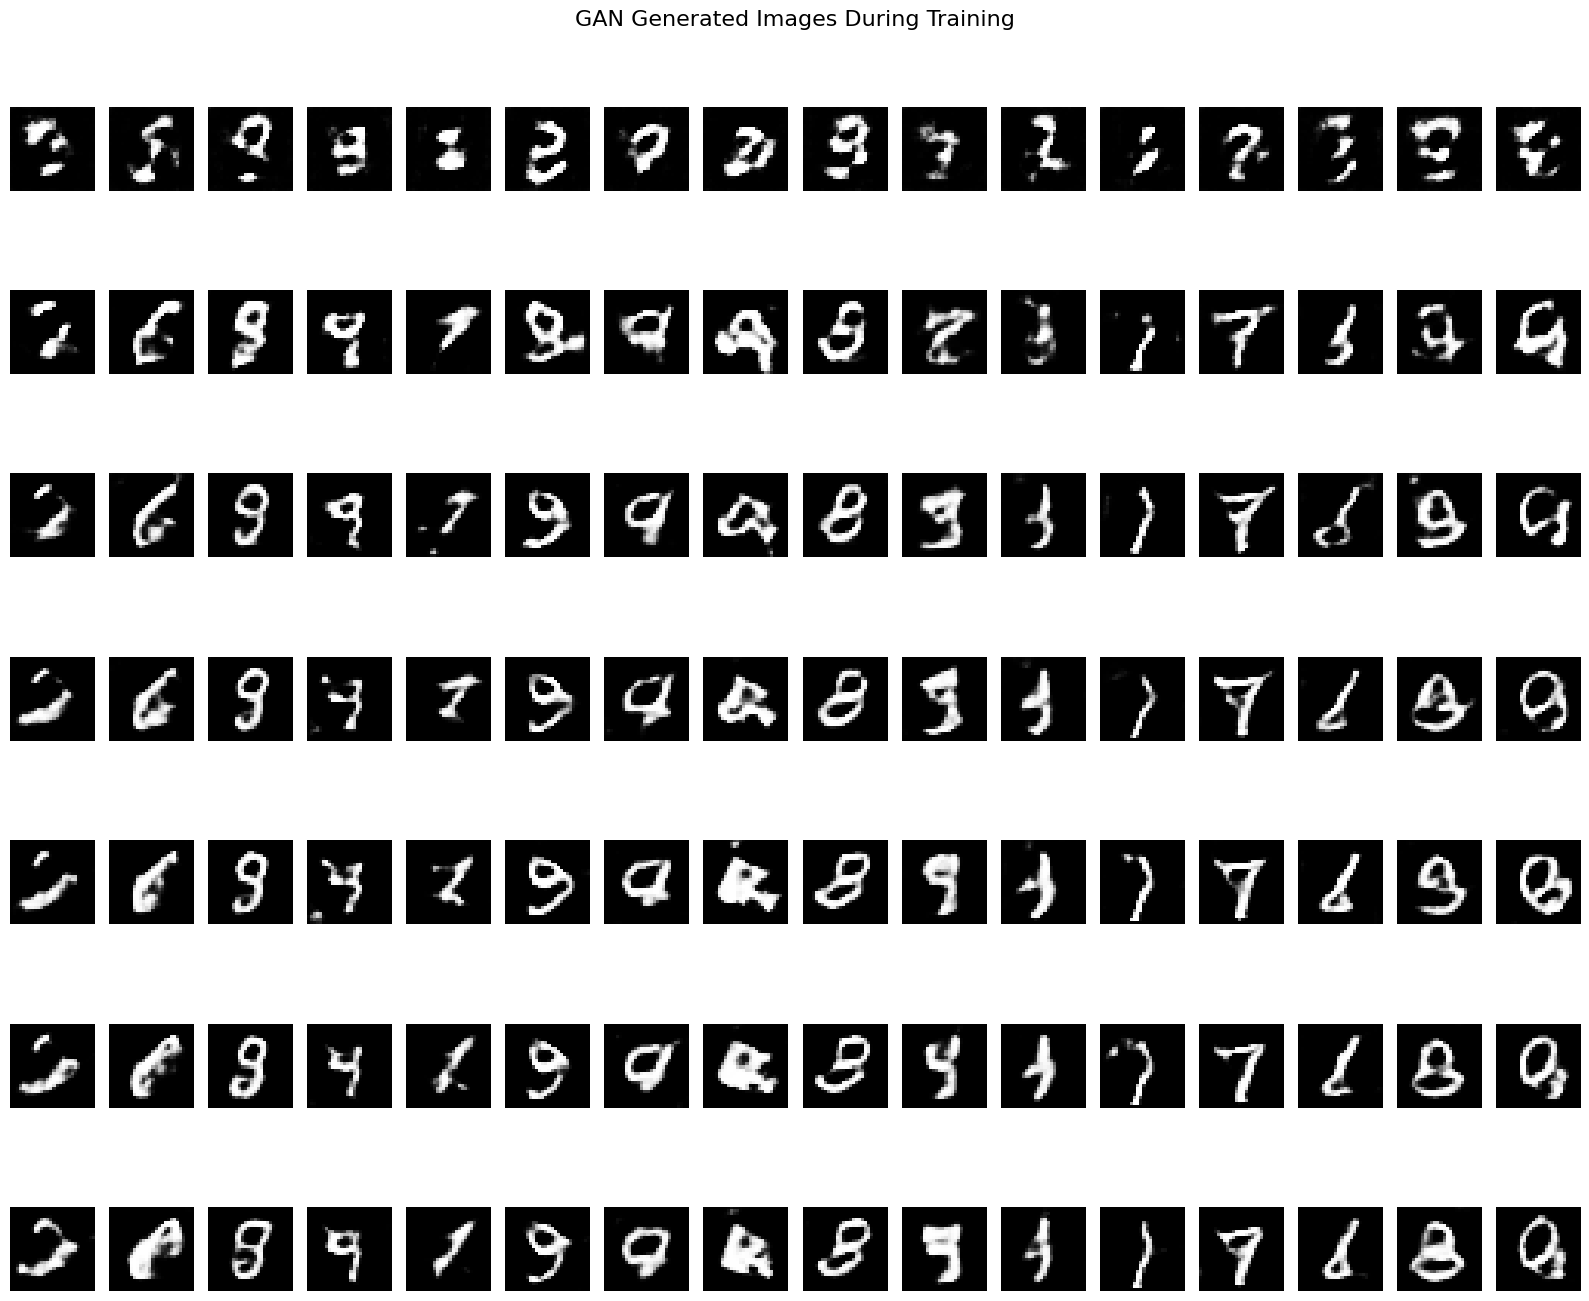

In [15]:
# Display generated images from different training stages
fig, axes = plt.subplots(
    len(generated_snapshots),
    16,
    figsize=(16, 2 * len(generated_snapshots))
)

if len(generated_snapshots) == 1:
    axes = np.expand_dims(axes, axis=0)

for row, (epoch, images) in enumerate(generated_snapshots):
    for col in range(16):
        axes[row, col].imshow(images[col, :, :, 0], cmap="gray")
        axes[row, col].axis("off")

    axes[row, 0].set_ylabel(
        f"Epoch {epoch}",
        rotation=90,
        fontsize=12
    )

plt.suptitle("GAN Generated Images During Training", fontsize=16)
plt.tight_layout()
plt.show()


# Loss Analysis

The Generator loss indicates how difficult it is for the Generator to fool the Discriminator. The Discriminator loss indicates how well it distinguishes real images from generated images. GAN losses do not necessarily decrease smoothly like conventional supervised learning losses, because both networks are continuously competing.


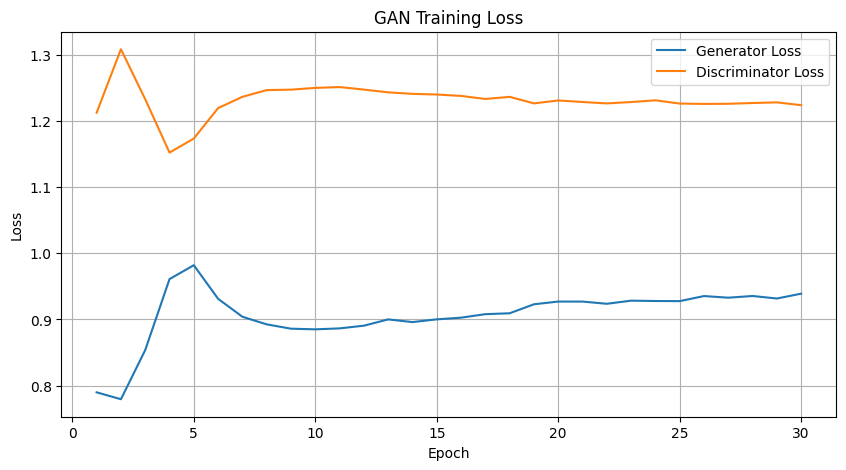

In [16]:
# Plot Generator and Discriminator losses
plt.figure(figsize=(10, 5))

plt.plot(
    range(1, EPOCHS + 1),
    generator_losses,
    label="Generator Loss"
)

plt.plot(
    range(1, EPOCHS + 1),
    discriminator_losses,
    label="Discriminator Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("GAN Training Loss")
plt.legend()
plt.grid(True)
plt.show()


# Compare Real Images with Generated Images


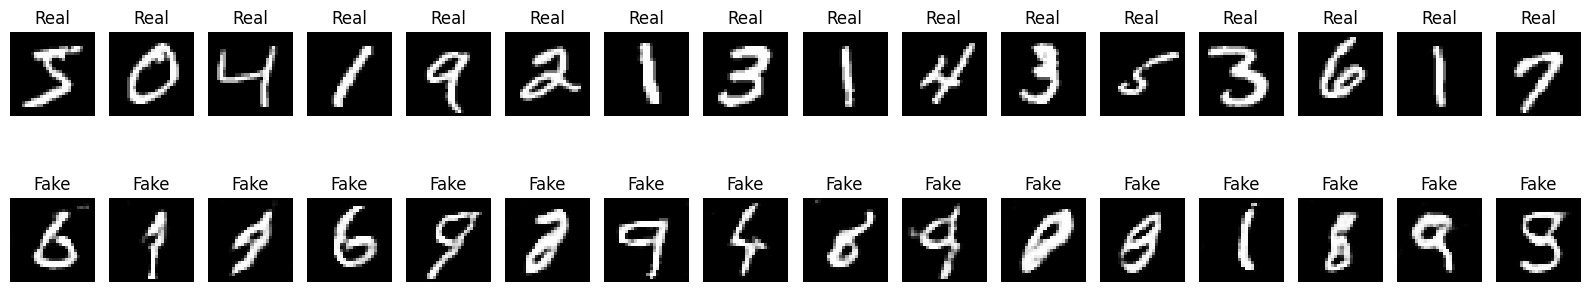

In [ ]:
# Display real MNIST images
real_images = x_train[:16]
# Generate synthetic images
final_noise = tf.random.normal([16, LATENT_DIM])
final_generated_images = generator(final_noise, training=False).numpy()
plt.figure(figsize=(16, 4))
for i in range(16):
    plt.subplot(2, 16, i + 1)
    plt.imshow(real_images[i, :, :, 0], cmap="gray")
    plt.title("Real")
    plt.axis("off")
    plt.subplot(2, 16, 16 + i + 1)
    plt.imshow(final_generated_images[i, :, :, 0], cmap="gray")
    plt.title("Fake")
    plt.axis("off")
plt.tight_layout()
plt.show()


# Save Final Generated Images

The generated images are saved as PNG files in a folder named `generated_images`. A ZIP file is also created for convenient download from Google Colab.


In [18]:
# Create output directory
output_dir = "generated_images"
os.makedirs(output_dir, exist_ok=True)

# Generate final images
num_final_images = 100
final_noise = tf.random.normal([num_final_images, LATENT_DIM])
final_images = generator(final_noise, training=False).numpy()

# Convert [-1, 1] back to [0, 255]
final_images_uint8 = (
    ((final_images + 1.0) * 127.5)
    .clip(0, 255)
    .astype(np.uint8)
)

# Save individual images
for i in range(num_final_images):
    image_path = os.path.join(output_dir, f"generated_{i+1:03d}.png")
    keras.utils.save_img(
        image_path,
        final_images_uint8[i],
        scale=False
    )

print(f"Saved {num_final_images} generated images to: {output_dir}")


Saved 100 generated images to: generated_images


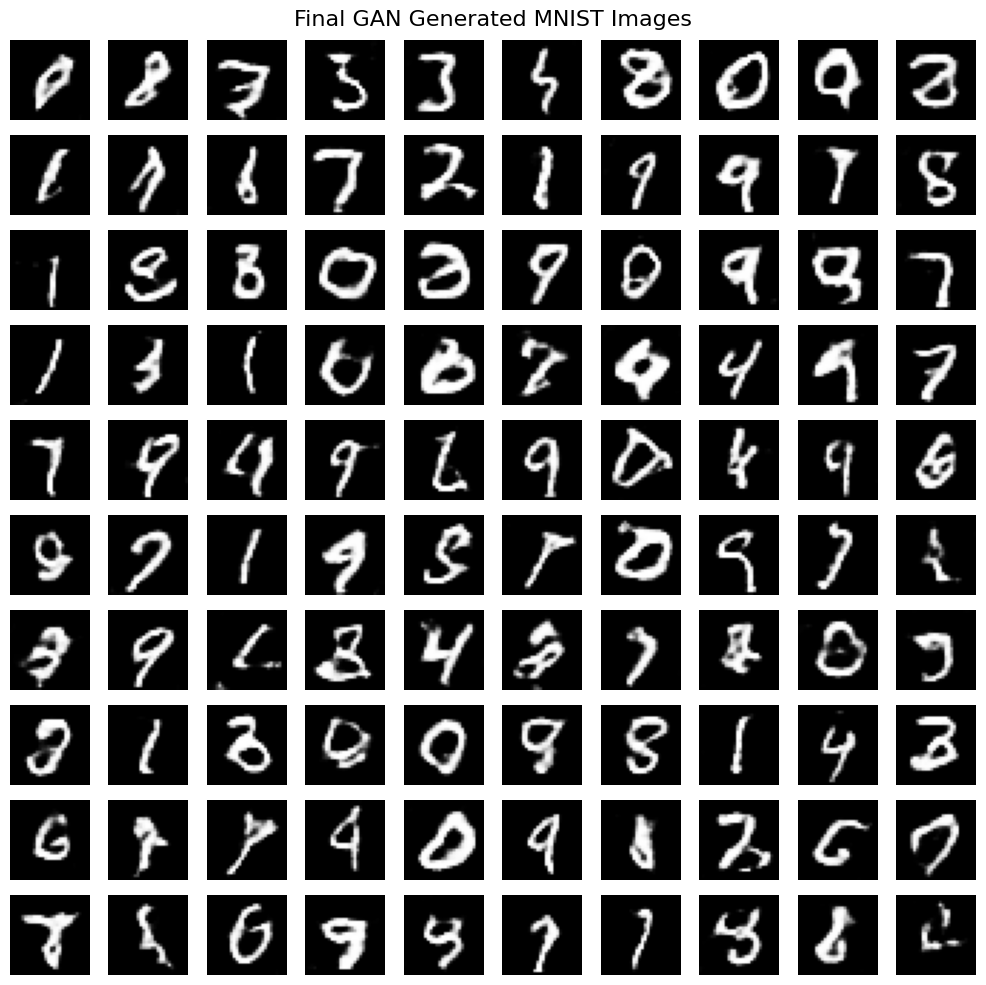

Contact sheet saved to: generated_images/final_contact_sheet.png


In [ ]:
fig = plt.figure(figsize=(10, 10))
for i in range(100):
    plt.subplot(10, 10, i + 1)
    plt.imshow(final_images_uint8[i, :, :, 0], cmap="gray")
    plt.axis("off")
plt.suptitle("Final GAN Generated MNIST Images", fontsize=16)
plt.tight_layout()
contact_sheet_path = "generated_images/final_contact_sheet.png"
plt.savefig(contact_sheet_path, dpi=150, bbox_inches="tight")
plt.show()
print("Contact sheet saved to:", contact_sheet_path)


In [20]:
# Create ZIP file containing generated images
import shutil

zip_path = shutil.make_archive(
    "GAN_generated_MNIST_images",
    "zip",
    output_dir
)

print("ZIP file created:", zip_path)


ZIP file created: d:\A1 1 10.0 1GC 10KT THIRD YEAR\SEM V\A1 10.0 DEEP LEARNING\DL LAB-7\GAN_generated_MNIST_images.zip


# Model Parameter Summary

The following cells display the total number of trainable parameters in the Generator and Discriminator.


In [21]:
# Display parameter counts
generator_params = generator.count_params()
discriminator_params = discriminator.count_params()

summary_df = pd.DataFrame({
    "Model": ["Generator", "Discriminator"],
    "Total Parameters": [generator_params, discriminator_params]
})

display(summary_df)


,Model,Total Parameters
0,Generator,858944
1,Discriminator,212865
